In [1]:
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from qiskit import transpile
from qiskit.circuit import Parameter,ParameterExpression
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeMumbaiV2
from qiskit.converters import circuit_to_dag, dag_to_circuit

import sys
sys.path.append("../")
from clapton.clapton import claptonize
from clapton.circuit_manipulation import transform_to_allowed_gates,qiskit_to_stim, modify_circuit, multi_angle_qaoa_circuit, transform_qiskit_to_stim,generate_qiskit_param_map,group_generate_qiskit_param_map
from testing_scripts.graphs_utils import generate_random_complete_graph,generate_k_regular_graph,compute_optimal_max_cut,build_max_cut_paulis
from testing_scripts.qaoa_utils import QAOASolver,evaluate_energy

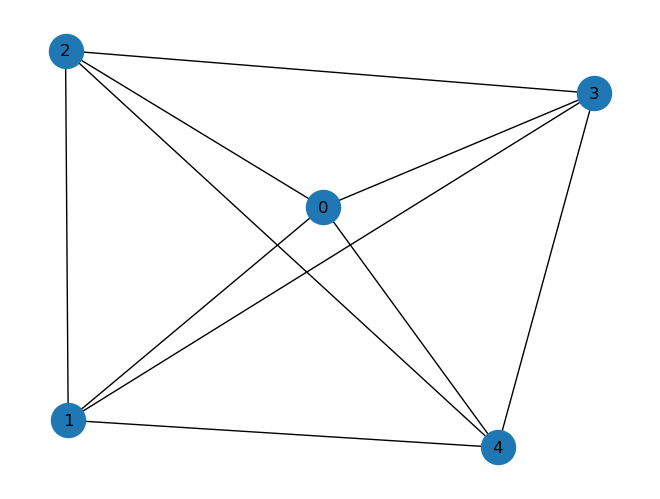

In [2]:
n = 5
k = 3 
G=generate_random_complete_graph(num_vertices=n, weighted=True, seed=True)
draw_graph(G, node_size=600, with_labels=True)

In [3]:
# Optimal Maxcut Calculation 
optimal_max_cut_val = compute_optimal_max_cut(G)
print(f"Optimal Max Cut Value : {optimal_max_cut_val}")

Optimal Max Cut Value : 43


In [4]:
max_cut_paulis = build_max_cut_paulis(G)

cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
print("Cost Function Hamiltonian:", cost_hamiltonian)

Cost Function Hamiltonian: SparsePauliOp(['IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[7.+0.j, 7.+0.j, 1.+0.j, 5.+0.j, 9.+0.j, 8.+0.j, 7.+0.j, 5.+0.j, 8.+0.j,
 6.+0.j])


In [5]:
reps = 1

#ma QAOA circuit
# circuit = multi_angle_qaoa_circuit(n,G ,reps)

#vanilla QAOA circuit 
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian,reps=reps)

In [6]:
circuit=circuit.decompose().decompose()
# circuit.draw('mpl')

In [7]:
circuit.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(γ[0])])

In [8]:
maxcut_qaoa = QAOASolver(cost_hamiltonian,circuit)
maxcut_qaoa.prepare_circuit(multi_angle=False)

In [9]:
group_dict = group_generate_qiskit_param_map(maxcut_qaoa.pcirc)
group_dict #wrong

{'γ[0]': [0, 1, 2, 3, 4, 5, 6, 8, 10, 12], 'β[0]': [7, 9, 11, 13, 14]}

In [10]:
# group_dict = {'β[0]': [0,1], 'γ[0]': [2]} #correct/working

In [11]:
#NOTE: Basically generate dict^ properly

In [12]:
#Run CAFQA process 
maxcut_qaoa.run_group_CAFQA(n_gens=10,group_dict=group_dict)

STARTING ROUND 0


started GA at id 1 with 1 procs

GA parameters used for this experiment:
  num_generations=5
  num_parents_mating=20
  population_size=100
  num_genes=2
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5started GA at id 2 with 1 procs
started GA at id None with 1 procs

GA parameters used for this experiment:
  num_generations=5
  num_parents_mating=20
  population_size=100
  num_genes=2
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5


started GA at id 3 with 1 procs
GA parameters used for this experiment:
  num_generations=5
  num_parents_mating=20
  population_size=100
  num_genes=2
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
 

# Now let's bruteforce

In [13]:
from scipy.optimize import minimize

def optimize_energy_discrete(circuit, cost_hamiltonian, initial_angles):
    def objective_function(params):
        # Map the parameters to the group_dict keys
        param_dict = {key: params[i] * (np.pi / 2) for i, key in enumerate(group_dict.keys())}
        energy = evaluate_energy(circuit, cost_hamiltonian, param_dict)
        print(f"Energy: {energy}, Parameters: {param_dict}")
        return energy

    # Initial guess for the parameters (scaled to integers 0-3)
    initial_params = [int(initial_angles[key] / (np.pi / 2)) for key in group_dict.keys()]

    # Bounds for the parameters (0 to 3, inclusive)
    bounds = [(0, 3) for _ in group_dict.keys()]

    # Perform optimization using scipy's minimize with L-BFGS-B method
    result = minimize(objective_function, initial_params, bounds=bounds, method='L-BFGS-B', options={'maxiter':100})

    # Convert optimized parameters back to angles
    optimized_angles = {key: result.x[i] * (np.pi / 2) for i, key in enumerate(group_dict.keys())}

    return result.fun, optimized_angles

# Example usage
initial_angles = {key: 0 for key in group_dict.keys()}
min_energy, optimized_angles = optimize_energy_discrete(circuit, cost_hamiltonian, initial_angles)
print(f"Minimum Energy: {min_energy}")
print(f"Optimized Angles: {optimized_angles}")


Energy: 0.0615234375, Parameters: {'γ[0]': np.float64(0.0), 'β[0]': np.float64(0.0)}
Energy: 0.5078125, Parameters: {'γ[0]': np.float64(1.5707963267948965e-08), 'β[0]': np.float64(0.0)}
Energy: -0.17626953125, Parameters: {'γ[0]': np.float64(0.0), 'β[0]': np.float64(1.5707963267948965e-08)}
Energy: -0.2373046875, Parameters: {'γ[0]': np.float64(0.0), 'β[0]': np.float64(4.71238898038469)}
Energy: -0.5048828125, Parameters: {'γ[0]': np.float64(1.5707963267948965e-08), 'β[0]': np.float64(4.71238898038469)}
Energy: -0.1318359375, Parameters: {'γ[0]': np.float64(0.0), 'β[0]': np.float64(4.712388964676727)}
Energy: 0.07275390625, Parameters: {'γ[0]': np.float64(0.0), 'β[0]': np.float64(1.2634853532463797)}
Energy: -0.35546875, Parameters: {'γ[0]': np.float64(1.5707963267948965e-08), 'β[0]': np.float64(1.2634853532463797)}
Energy: 0.12158203125, Parameters: {'γ[0]': np.float64(0.0), 'β[0]': np.float64(1.263485368954343)}
Energy: 0.02783203125, Parameters: {'γ[0]': np.float64(0.0), 'β[0]': np.